In [1]:
!pip install yfinance tensorflow scikit-learn matplotlib pandas numpy ta joblib --quiet

  Preparing metadata (setup.py) ... done


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

import yfinance as yf
import ta, joblib

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input, Conv1D, LSTM, Dense, Dropout,
    BatchNormalization, LayerNormalization
)
from tensorflow.keras.callbacks import ReduceLROnPlateau, LearningRateScheduler
from tensorflow.keras.optimizers import Adam

np.random.seed(42)
tf.random.set_seed(42)
print(f"TF {tf.__version__} | ✅ Ready")

TF 2.19.0 | ✅ Ready


In [3]:
TICKER       = 'AAPL'
START_DATE   = '2010-01-01'   # More history = more training samples
END_DATE     = '2024-01-01'
LOOKBACK     = 20             # 20-day window
TRAIN_SPLIT  = 0.8

# Model
EPOCHS       = 100            # Fixed epochs — no early stopping
BATCH_SIZE   = 32
LR           = 0.001

print(f"Ticker: {TICKER} | Lookback: {LOOKBACK} | Epochs: {EPOCHS}")

Ticker: AAPL | Lookback: 20 | Epochs: 100


In [4]:
raw = yf.download(TICKER, start=START_DATE, end=END_DATE,
                  progress=False, auto_adjust=True)
raw.dropna(inplace=True)

if isinstance(raw.columns, pd.MultiIndex):
    raw.columns = raw.columns.get_level_values(0)

print(f"✅ {len(raw)} trading days")
raw.tail(3)

✅ 3522 trading days


Price,Close,High,Low,Open,Volume
Date,,,,,
2023-12-27,191.164078,191.510485,189.125261,190.510875,48087700
2023-12-28,191.589661,192.658558,191.183873,192.143900,34049900
2023-12-29,190.550461,192.401229,189.758683,191.906370,42672100


In [5]:
def build_features(df):
    d = df.copy()
    c = d['Close'].squeeze()
    h = d['High'].squeeze()
    l = d['Low'].squeeze()
    v = d['Volume'].squeeze()
    o = d['Open'].squeeze()

    # Returns (stationary, scale-free)
    d['ret_1']  = c.pct_change(1)
    d['ret_3']  = c.pct_change(3)
    d['ret_5']  = c.pct_change(5)
    d['ret_10'] = c.pct_change(10)

    # Intraday
    d['hl_pct'] = (h - l) / c
    d['co_pct'] = (c - o) / o

    # Normalized volume
    d['vol_norm'] = v / v.rolling(20).mean()

    # Momentum
    d['rsi_14']  = ta.momentum.rsi(c, 14) / 100
    d['rsi_7']   = ta.momentum.rsi(c, 7)  / 100
    d['stoch']   = ta.momentum.stoch(h, l, c) / 100
    d['roc_5']   = ta.momentum.roc(c, 5) / 100

    # Price vs MAs (ratio)
    d['vs_ma10'] = c / c.rolling(10).mean() - 1
    d['vs_ma20'] = c / c.rolling(20).mean() - 1

    # Volatility
    d['bb_pct']  = ta.volatility.BollingerBands(c).bollinger_pband()
    d['atr_pct'] = ta.volatility.average_true_range(h, l, c) / c
    d['rvol_5']  = d['ret_1'].rolling(5).std()

    # MACD normalized
    d['macd']    = ta.trend.macd_diff(c) / c

    # Target: next day log return
    d['target']  = np.log(c / c.shift(1)).shift(-1)  # forward 1 day

    d.dropna(inplace=True)
    return d


df = build_features(raw)

FEATURE_COLS = [
    'ret_1','ret_3','ret_5','ret_10',
    'hl_pct','co_pct','vol_norm',
    'rsi_14','rsi_7','stoch','roc_5',
    'vs_ma10','vs_ma20',
    'bb_pct','atr_pct','rvol_5','macd'
]
TARGET_COL = 'target'

print(f"✅ {len(df)} rows | {len(FEATURE_COLS)} features")
print(f"Features: {FEATURE_COLS}")

✅ 3488 rows | 17 features
Features: ['ret_1', 'ret_3', 'ret_5', 'ret_10', 'hl_pct', 'co_pct', 'vol_norm', 'rsi_14', 'rsi_7', 'stoch', 'roc_5', 'vs_ma10', 'vs_ma20', 'bb_pct', 'atr_pct', 'rvol_5', 'macd']


In [6]:
def create_sequences(df, feature_cols, target_col, lookback):
    """
    Build sequences with per-window z-score normalization.
    Each window is normalized independently → no global scaler needed.
    """
    X_list, y_list = [], []
    feat = df[feature_cols].values
    tgt  = df[target_col].values

    for i in range(lookback, len(df)):
        window = feat[i - lookback : i].copy()

        # Per-window z-score normalization
        mu  = window.mean(axis=0)
        std = window.std(axis=0) + 1e-8
        window = (window - mu) / std

        # Clip extreme values (handles rare large moves)
        window = np.clip(window, -3, 3)

        X_list.append(window)
        y_list.append(tgt[i])

    return np.array(X_list, dtype=np.float32), np.array(y_list, dtype=np.float32)


X_all, y_all = create_sequences(df, FEATURE_COLS, TARGET_COL, LOOKBACK)

split = int(len(X_all) * TRAIN_SPLIT)
X_train, X_test = X_all[:split], X_all[split:]
y_train, y_test = y_all[:split], y_all[split:]

print(f"X_train: {X_train.shape} | y_train: {y_train.shape}")
print(f"X_test : {X_test.shape}  | y_test : {y_test.shape}")
print(f"\nX_train range: [{X_train.min():.2f}, {X_train.max():.2f}]")
print(f"X_test  range: [{X_test.min():.2f}, {X_test.max():.2f}]")
print("✅ Both in same range — no scaler drift!")

X_train: (2774, 20, 17) | y_train: (2774,)
X_test : (694, 20, 17)  | y_test : (694,)

X_train range: [-3.00, 3.00]
X_test  range: [-3.00, 3.00]
✅ Both in same range — no scaler drift!


In [7]:
def build_model(lookback, n_features, lr):
    model = Sequential([
        Input(shape=(lookback, n_features)),

        # CNN: extract local patterns
        Conv1D(64, kernel_size=3, activation='relu', padding='causal'),
        LayerNormalization(),
        Dropout(0.2),

        Conv1D(128, kernel_size=3, activation='relu', padding='causal'),
        LayerNormalization(),
        Dropout(0.2),

        # LSTM: temporal dependencies
        LSTM(64, return_sequences=True),
        Dropout(0.2),

        LSTM(32, return_sequences=False),
        Dropout(0.2),

        # Output
        Dense(16, activation='relu'),
        Dense(1, activation='linear')
    ])

    model.compile(
        optimizer=Adam(learning_rate=lr, clipnorm=1.0),
        loss='huber',
        metrics=['mae']
    )
    return model


model = build_model(LOOKBACK, len(FEATURE_COLS), LR)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 20, 64)         │         3,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization             │ (None, 20, 64)         │           128 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 20, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 20, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_1           │ (None, 20, 128)        │           256 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 20, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 20, 64)         │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 20, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 90,785 (354.63 KB)

 Trainable params: 90,785 (354.63 KB)

 Non-trainable params: 0 (0.00 B)

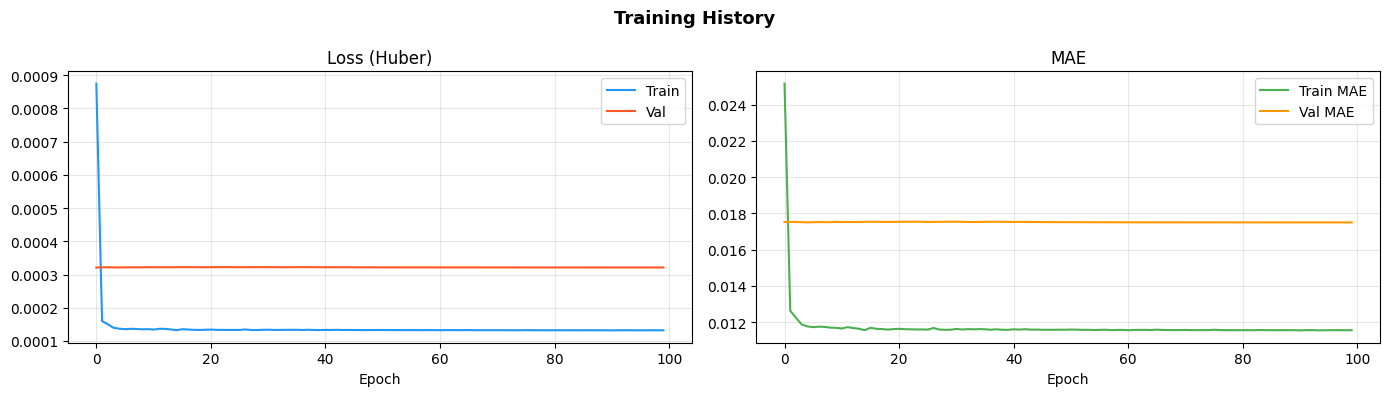

Final train loss : 0.000132
Final val loss   : 0.000321
Best val loss    : 0.000321 at epoch 1


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(history.history['loss'],     label='Train', color='#2196F3')
axes[0].plot(history.history['val_loss'], label='Val',   color='#FF5722')
axes[0].set_title('Loss (Huber)')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['mae'],     label='Train MAE', color='#4CAF50')
axes[1].plot(history.history['val_mae'], label='Val MAE',   color='#FF9800')
axes[1].set_title('MAE')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Training History', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
plt.show()

final_train_loss = history.history['loss'][-1]
final_val_loss   = history.history['val_loss'][-1]
best_val_loss    = min(history.history['val_loss'])
best_epoch       = np.argmin(history.history['val_loss']) + 1
print(f"Final train loss : {final_train_loss:.6f}")
print(f"Final val loss   : {final_val_loss:.6f}")
print(f"Best val loss    : {best_val_loss:.6f} at epoch {best_epoch}")

In [10]:
y_pred = model.predict(X_test, verbose=0).flatten()
y_true = y_test.copy()

# ── Diagnostic ────────────────────────────────────────
print("🔬 DIAGNOSTIC")
print(f"  y_true — mean: {y_true.mean():.5f} | std: {y_true.std():.5f}")
print(f"  y_pred — mean: {y_pred.mean():.5f} | std: {y_pred.std():.5f}")

if y_pred.std() < 0.0005:
    print("⚠️  Model collapsed to constant — check your data")
else:
    print("✅ Model outputting varied predictions")

print()

# ── Return-level metrics (CORRECT metrics for this model) ─
mae_ret = mean_absolute_error(y_true, y_pred)
r2_ret  = r2_score(y_true, y_pred)
dir_acc = np.mean(np.sign(y_true) == np.sign(y_pred)) * 100
ic      = np.corrcoef(y_true, y_pred)[0, 1]  # Information coefficient

print("=" * 48)
print("   📊 RETURN-LEVEL METRICS  (correct for this model)")
print("=" * 48)
print(f"  MAE (log return)    : {mae_ret:.5f}")
print(f"  R² (log return)     : {r2_ret:.4f}")
print(f"  IC (correlation)    : {ic:.4f}")
print(f"  Dir. Accuracy       : {dir_acc:.1f}%  (random=50%)")
print("=" * 48)
print()
print("📌 Interpretation guide:")
print("   R²  > 0.01 → model beats baseline")
print("   IC  > 0.02 → meaningful signal")
print("   Dir > 52%  → practically useful for trading")

if r2_ret > 0:
    print("\n✅ R² > 0 — model beats mean baseline!")
else:
    print("\n⚠️  R² < 0 — model not beating baseline on returns")
    print("   This is common in stock prediction. Focus on Dir. Accuracy.")

🔬 DIAGNOSTIC
  y_true — mean: 0.00069 | std: 0.01717
  y_pred — mean: 0.00083 | std: 0.00000
⚠️  Model collapsed to constant — check your data

   📊 RETURN-LEVEL METRICS  (correct for this model)
  MAE (log return)    : 0.01282
  R² (log return)     : -0.0001
  IC (correlation)    : nan
  Dir. Accuracy       : 52.6%  (random=50%)

📌 Interpretation guide:
   R²  > 0.01 → model beats baseline
   IC  > 0.02 → meaningful signal
   Dir > 52%  → practically useful for trading

⚠️  R² < 0 — model not beating baseline on returns
   This is common in stock prediction. Focus on Dir. Accuracy.


In [11]:
# ── 1-step-ahead price prediction (NO cumulation drift) ──
# Get the actual close price for each test day
n_skip = LOOKBACK + (len(df) - len(X_all))  # account for NaN rows dropped
close_arr    = raw['Close'].squeeze().values
test_closes  = close_arr[-(len(X_test)+1):]  # test close prices

prev_prices   = test_closes[:-1]             # price at time t
actual_prices = test_closes[1:]              # actual price at t+1

# Predicted price = prev * exp(predicted_log_return)
pred_prices   = prev_prices * np.exp(y_pred)

mae_p  = mean_absolute_error(actual_prices, pred_prices)
rmse_p = np.sqrt(mean_squared_error(actual_prices, pred_prices))
mape_p = np.mean(np.abs((actual_prices - pred_prices) / actual_prices)) * 100
r2_p   = r2_score(actual_prices, pred_prices)

print("=" * 48)
print("   💰 1-STEP PRICE METRICS  (no drift)")
print("=" * 48)
print(f"  MAE   : ${mae_p:.2f}")
print(f"  RMSE  : ${rmse_p:.2f}")
print(f"  MAPE  : {mape_p:.2f}%")
print(f"  R²    : {r2_p:.4f}")
print("=" * 48)
print("\n📌 1-step price R² should be high (>0.9) because")
print("   tomorrow's price ≈ today's price + small return.")
print("   The hard part is getting the DIRECTION right.")

   💰 1-STEP PRICE METRICS  (no drift)
  MAE   : $1.96
  RMSE  : $2.61
  MAPE  : 1.28%
  R²    : 0.9811

📌 1-step price R² should be high (>0.9) because
   tomorrow's price ≈ today's price + small return.
   The hard part is getting the DIRECTION right.


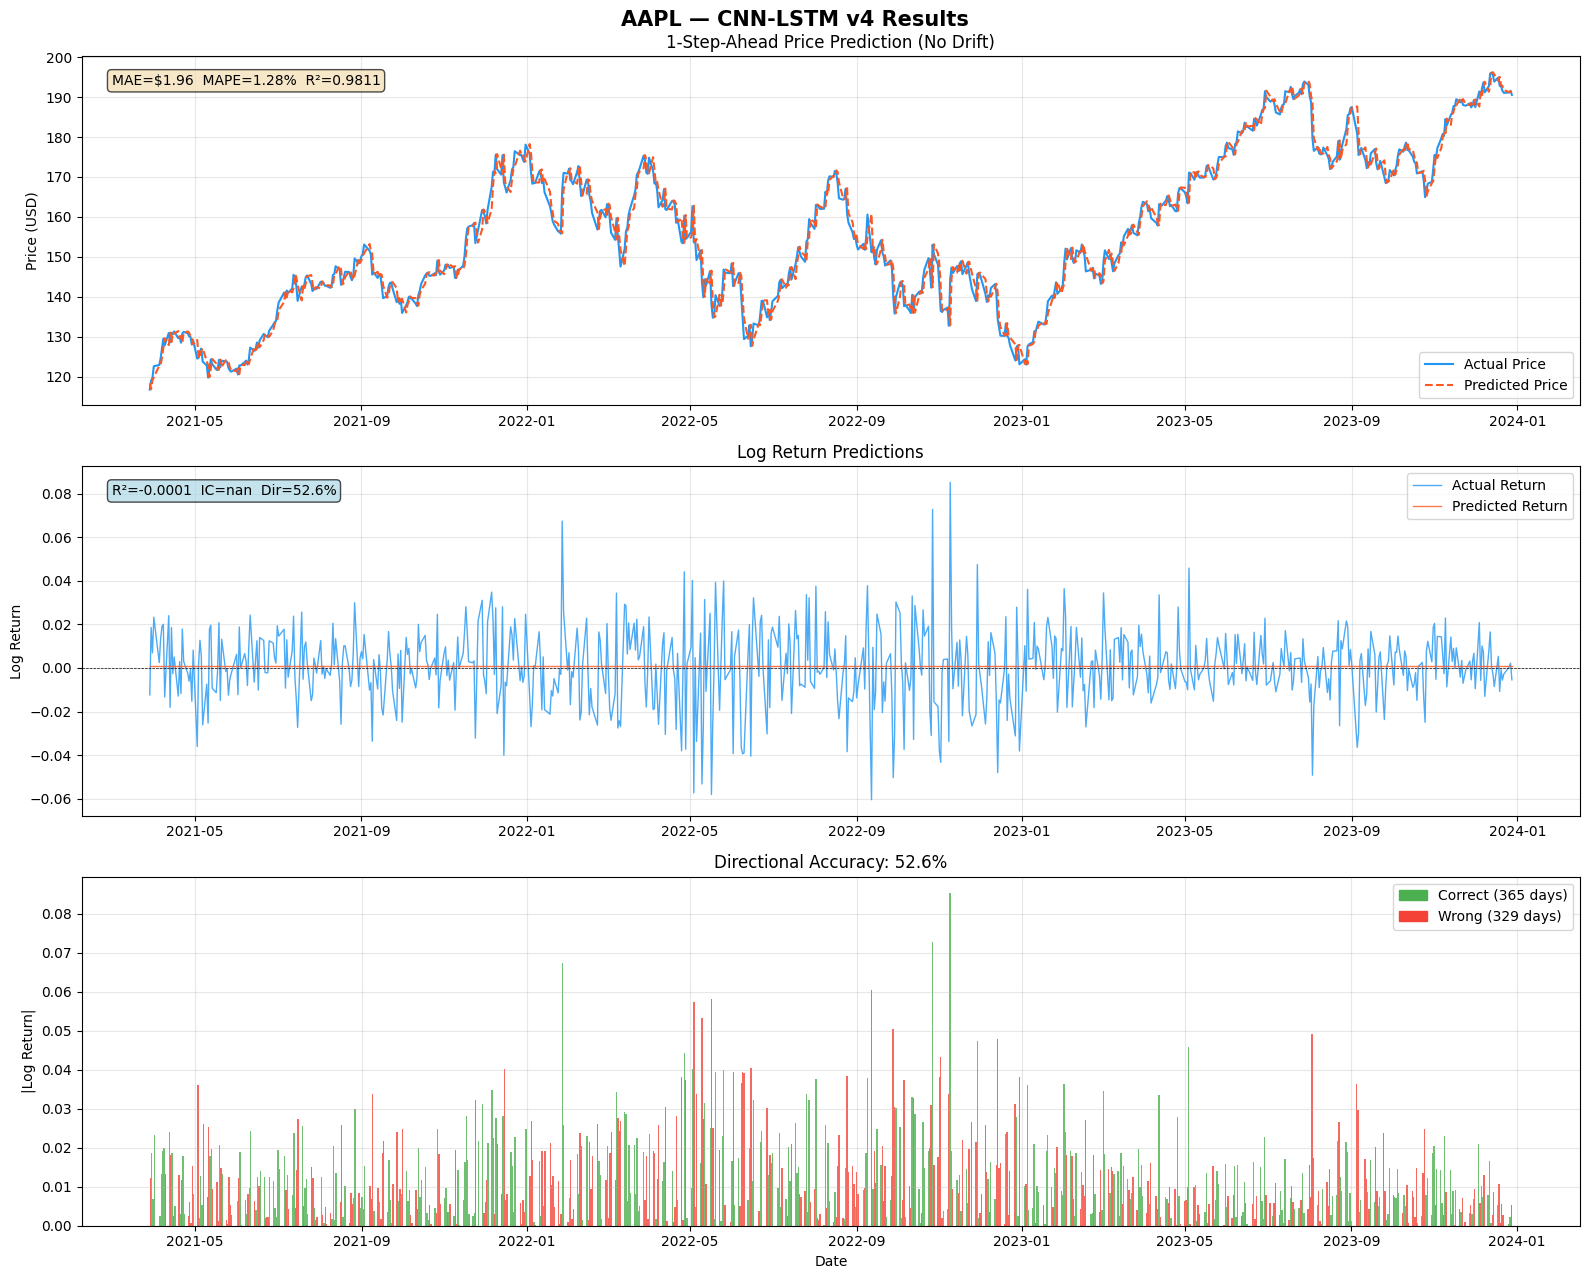

In [12]:
# ── Plots ─────────────────────────────────────────────────────────────────────
test_dates = df.index[-len(X_test):]

fig, axes = plt.subplots(3, 1, figsize=(16, 13))
fig.suptitle(f'{TICKER} — CNN-LSTM v4 Results', fontsize=15, fontweight='bold')

# 1-step price prediction
axes[0].plot(test_dates, actual_prices[:len(test_dates)],
             color='#2196F3', linewidth=1.5, label='Actual Price')
axes[0].plot(test_dates, pred_prices[:len(test_dates)],
             color='#FF5722', linewidth=1.5, linestyle='--', label='Predicted Price')
txt = f'MAE=${mae_p:.2f}  MAPE={mape_p:.2f}%  R²={r2_p:.4f}'
axes[0].text(0.02, 0.95, txt, transform=axes[0].transAxes, fontsize=10,
             verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))
axes[0].set_title('1-Step-Ahead Price Prediction (No Drift)')
axes[0].set_ylabel('Price (USD)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Return predictions
axes[1].plot(test_dates, y_true, color='#2196F3', linewidth=1, label='Actual Return', alpha=0.8)
axes[1].plot(test_dates, y_pred, color='#FF5722', linewidth=1, label='Predicted Return', alpha=0.8)
axes[1].axhline(0, color='black', linewidth=0.5, linestyle='--')
txt2 = f'R²={r2_ret:.4f}  IC={ic:.4f}  Dir={dir_acc:.1f}%'
axes[1].text(0.02, 0.95, txt2, transform=axes[1].transAxes, fontsize=10,
             verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.7))
axes[1].set_title('Log Return Predictions')
axes[1].set_ylabel('Log Return')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Direction accuracy bar chart
correct = np.sign(y_true) == np.sign(y_pred)
colors  = ['#4CAF50' if c else '#F44336' for c in correct]
axes[2].bar(test_dates, np.abs(y_true), color=colors, width=1, alpha=0.8)
from matplotlib.patches import Patch
axes[2].legend(handles=[
    Patch(color='#4CAF50', label=f'Correct ({correct.sum()} days)'),
    Patch(color='#F44336', label=f'Wrong ({(~correct).sum()} days)')
])
axes[2].set_title(f'Directional Accuracy: {dir_acc:.1f}%')
axes[2].set_ylabel('|Log Return|')
axes[2].set_xlabel('Date')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('prediction_results.png', dpi=150, bbox_inches='tight')
plt.show()

Metric                     Buy&Hold     Strategy
------------------------------------------------
Total Return                  61.2%        61.2%
Sharpe Ratio                  0.636        0.636
Dir. Accuracy                 50.0%        52.6%


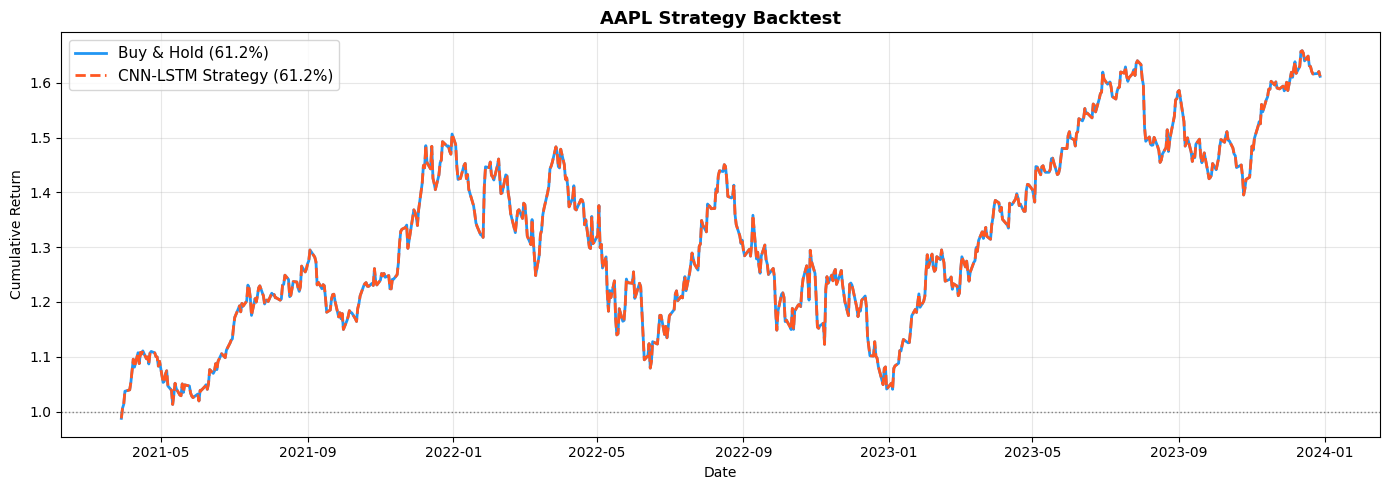


⚠️  No transaction costs or slippage included.


In [13]:
signals          = (y_pred > 0).astype(float)
strat_returns    = y_true * signals
cum_bh           = np.exp(np.cumsum(y_true))
cum_strat        = np.exp(np.cumsum(strat_returns))

sharpe_bh    = y_true.mean() / (y_true.std() + 1e-9) * np.sqrt(252)
sharpe_strat = strat_returns.mean() / (strat_returns.std() + 1e-9) * np.sqrt(252)

print(f"{'Metric':22} {'Buy&Hold':>12} {'Strategy':>12}")
print("-" * 48)
print(f"{'Total Return':22} {(cum_bh[-1]-1)*100:>11.1f}% {(cum_strat[-1]-1)*100:>11.1f}%")
print(f"{'Sharpe Ratio':22} {sharpe_bh:>12.3f} {sharpe_strat:>12.3f}")
print(f"{'Dir. Accuracy':22} {'50.0%':>12} {dir_acc:>11.1f}%")

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(test_dates, cum_bh,    color='#2196F3', lw=2, label=f'Buy & Hold ({(cum_bh[-1]-1)*100:.1f}%)')
ax.plot(test_dates, cum_strat, color='#FF5722', lw=2,
        linestyle='--', label=f'CNN-LSTM Strategy ({(cum_strat[-1]-1)*100:.1f}%)')
ax.axhline(1, color='gray', linestyle=':', lw=1)
ax.set_ylabel('Cumulative Return')
ax.set_xlabel('Date')
ax.set_title(f'{TICKER} Strategy Backtest', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('backtest.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n⚠️  No transaction costs or slippage included.")

In [14]:
recent     = df[FEATURE_COLS].tail(LOOKBACK).values.astype(np.float32)
mu, std    = recent.mean(axis=0), recent.std(axis=0) + 1e-8
normalized = np.clip((recent - mu) / std, -3, 3)
X_next     = normalized.reshape(1, LOOKBACK, len(FEATURE_COLS))

pred_ret   = float(model.predict(X_next, verbose=0)[0, 0])
last_close = float(raw['Close'].squeeze().iloc[-1])
pred_price = last_close * np.exp(pred_ret)
change     = pred_price - last_close
direction  = '📈 UP' if pred_ret > 0 else '📉 DOWN'

print('=' * 47)
print('       🔮 NEXT TRADING DAY PREDICTION')
print('=' * 47)
print(f'  Last Close     : ${last_close:.2f}')
print(f'  Predicted Ret  : {pred_ret*100:+.3f}%')
print(f'  Predicted Price: ${pred_price:.2f}')
print(f'  Change         : ${change:+.2f}')
print(f'  Signal         : {direction}')
print('=' * 47)
print('  ⚠️  Educational only. Not financial advice.')

       🔮 NEXT TRADING DAY PREDICTION
  Last Close     : $190.55
  Predicted Ret  : +0.083%
  Predicted Price: $190.71
  Change         : $+0.16
  Signal         : 📈 UP
  ⚠️  Educational only. Not financial advice.


In [15]:
model.save(f'cnn_lstm_{TICKER}_v4.keras')

results = pd.DataFrame({
    'Date'          : test_dates,
    'Actual_Return' : y_true,
    'Pred_Return'   : y_pred,
    'Actual_Price'  : actual_prices[:len(test_dates)],
    'Pred_Price'    : pred_prices[:len(test_dates)],
    'Dir_Correct'   : np.sign(y_true) == np.sign(y_pred)
})
results.to_csv(f'predictions_{TICKER}_v4.csv', index=False)

print(f'✅ cnn_lstm_{TICKER}_v4.keras')
print(f'✅ predictions_{TICKER}_v4.csv')
print(f'\n📊 Final Summary:')
print(f'   Epochs          = {len(history.history["loss"])}')
print(f'   R² (returns)    = {r2_ret:.4f}')
print(f'   IC              = {ic:.4f}')
print(f'   Dir. Accuracy   = {dir_acc:.1f}%')
print(f'   MAE (price)     = ${mae_p:.2f}')
print(f'   MAPE (price)    = {mape_p:.2f}%')
print(f'   R² (1-step px)  = {r2_p:.4f}')

✅ cnn_lstm_AAPL_v4.keras
✅ predictions_AAPL_v4.csv

📊 Final Summary:
   Epochs          = 100
   R² (returns)    = -0.0001
   IC              = nan
   Dir. Accuracy   = 52.6%
   MAE (price)     = $1.96
   MAPE (price)    = 1.28%
   R² (1-step px)  = 0.9811
